## This is a notebook to get parameters from sit tier

In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np
import lh5
import awkward as ak

In [2]:
import importlib
from pytools4scarf import dataloader
importlib.reload(dataloader)

<module 'pytools4scarf.dataloader' from '/mnt/atlas02/users/leoli/software/pytools4scarf/src/pytools4scarf/dataloader.py'>

In [3]:
from pathlib import Path
map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s500ns_mw7')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s500ns_mw7.yaml'

## Event tier data and masks.

In [ ]:
dfs_evt,lts_evt = {},{}

dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_evt["r060"], lts_evt["r060"] = dataloader.load_lh5_run(
#     ["ch002/evt"],
#     "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
#     data_cleaning_path,
#     "evt",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )
# dfs_evt["r038"], lts_evt["r038"] = dataloader.load_lh5_run(
#     ["ch002/evt"],
#     "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
#     data_cleaning_path,
#     "evt",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )


In [ ]:
# masks for physical events, which are defined as events with A_max_mw_o_E_fix_Classifier < 3, Iasy < 0, and not pulser or muon events, and valid waveform.
r059_masks = (
    (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& ~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
# r038_masks = (
#     (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r038']['ch002'].Iasy<0)
# & ~(dfs_evt['r038']['ch002'].is_pulser)            
# & ~(dfs_evt['r038']['ch002'].is_muon)
# & (dfs_evt['r038']['ch002'].is_valid_waveform)
# )
# r060_masks = ((dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r060']['ch002'].Iasy<0)
# & ~(dfs_evt['r060']['ch002'].is_pulser)            
# & ~(dfs_evt['r060']['ch002'].is_muon)
# & (dfs_evt['r060']['ch002'].is_valid_waveform)
# )
# for the HE events, we want to select only the muon events, and exclude pulser events.
r059_he_masks = (
~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
# r038_he_masks = (
# ~(dfs_evt['r038']['ch002'].is_pulser)            
# & ~(dfs_evt['r038']['ch002'].is_muon)
# & (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r038']['ch002'].Iasy<0)
# & (dfs_evt['r038']['ch002'].is_valid_waveform)
# )
# r060_he_masks = (
# ~(dfs_evt['r060']['ch002'].is_pulser)            
# & ~(dfs_evt['r060']['ch002'].is_muon)
# & (dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r060']['ch002'].Iasy<0)
# & (dfs_evt['r060']['ch002'].is_valid_waveform)
# )

r059_argon_mask = (dfs_evt['r059']['ch002'].is_lar_vetoed)
# r060_argon_mask = (dfs_evt['r060']['ch002'].is_lar_vetoed)

## sit tier analysis 

### Combined Cut


In [ ]:
# candidate = best_candidates[0]
candidate ='s500ns_mw3'

dfs_sit_candidate, lts_sit_candidate = {}, {}
# dfs_sit_candidate["r038"], lts_sit_candidate["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_candidate["r059"], lts_sit_candidate["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_candidate["r060"], lts_sit_candidate["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [ ]:
# candidate = best_candidates[0]
candidate_2 ='s40ns_mw7'

dfs_sit_candidate_2, lts_sit_candidate_2 = {}, {}
# dfs_sit_candidate_2["r038"], lts_sit_candidate_2["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_candidate_2["r059"], lts_sit_candidate_2["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate_2),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_candidate_2["r060"], lts_sit_candidate_2["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [ ]:
gamma_r059 = ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<2424.3+5))
gamma_r038 = ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<2424.3+5))
gamma_r060 = ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<2424.3+5))
candidate_roi_mask_r038 = (
(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r038) 
)
candidate_roi_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r059)
)
candidate_roi_mask_r060 = (
(dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r060)
)
candidate_he_mask_r038 = (
(dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 6000)
& (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 10000)
)
candidate_he_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 6000)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 10000)
)
candidate_he_mask_r060 = (
(dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 6000)
& (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 10000)
)


KeyError: 'r038'

### scarf default

In [ ]:
default='s100ns_mw5'

dfs_sit_default, lts_sit_default = {}, {}
# dfs_sit_default["r038"], lts_sit_default["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(default),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_default["r059"], lts_sit_default["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(default),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_default["r060"], lts_sit_default["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(default),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [ ]:
selection_r059 = (
    candidate_roi_mask_r059 # not alpha, not pulser, not muon,
    & r059_masks # ROI mask with gamma line masks
    # & ~r059_argon_mask
    & (
        (
            (dfs_sit_candidate["r059"]["ch002"].A_max_mw_o_E_fix_Classifier<-0.94)
            &~(dfs_sit_candidate_2["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
        )
        # & ~(dfs_sit_default["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
    )
)
selection_r059 = np.asarray(selection_r059)
np.sum(selection_r059)
    

NameError: name 'candidate_roi_mask_r059' is not defined

## plots

In [ ]:
# argon_mask = ak.concatenate([r059_argon_mask,r060_argon_mask])

In [ ]:
pathlist_raw={};lts_raw={}

pathlist_raw["r059"], lts_raw["r059"] = dataloader.load_lh5_run_filepath(
    ["ch002/raw"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "raw",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)

In [ ]:
# np.sum(mask)
# selection_r059 = masks["r059"]

In [ ]:
# first_50_indices = np.nonzero(selection_r059)[:50]
masked_data_raw = lh5.read('ch002/raw',pathlist_raw['r059'],idx=selection_r059)
# masked_data_raw = lh5.read('ch002/raw',pathlist_raw['r059'],idx=selection_r059[first_50_indices])


In [ ]:
print(np.array_equal(masked_data_raw['timestamp'], dfs_sit_candidate['r059']['ch002'][selection_r059].timestamp))

True


In [ ]:
masked_data_raw["timestamp"]

Array([1.70802133e+09 1.70802444e+09 1.70802766e+09 ... 1.70905286e+09
       1.70908988e+09 1.70910015e+09], attrs={'datatype': 'array<1>{real}', 'units': 's'})

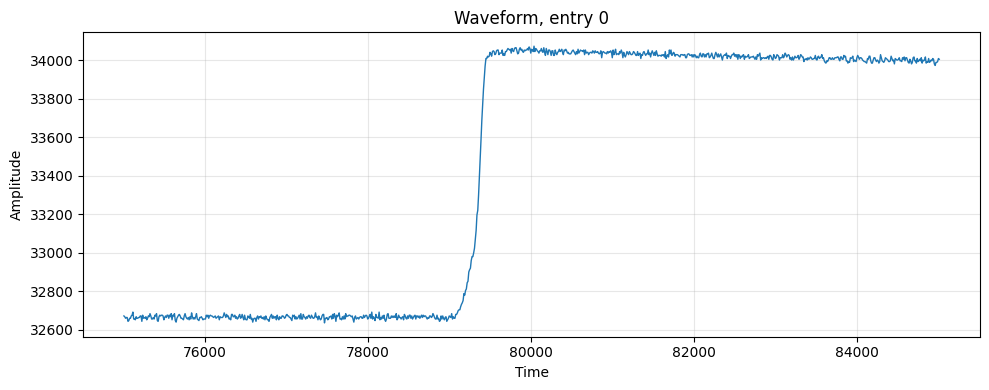

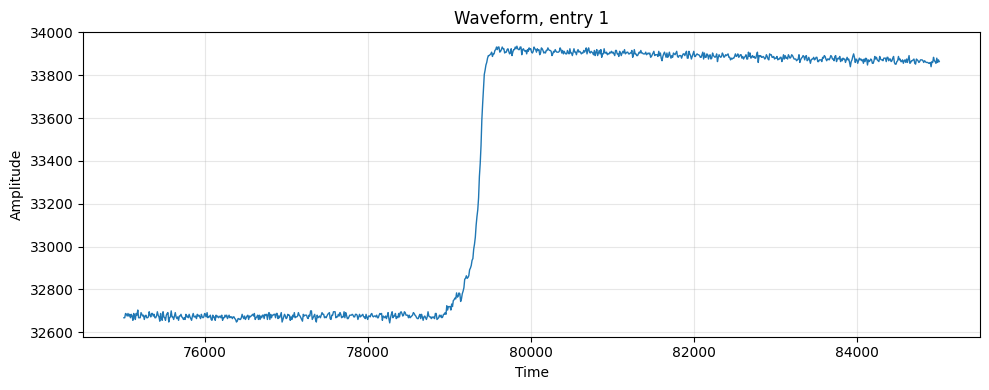

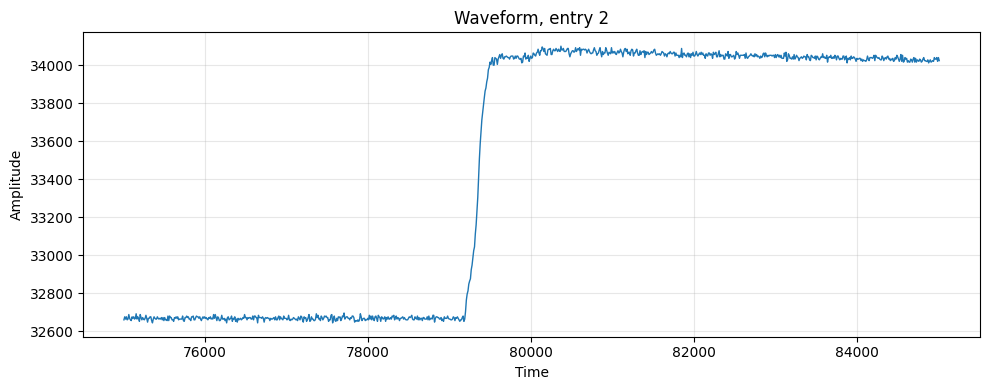

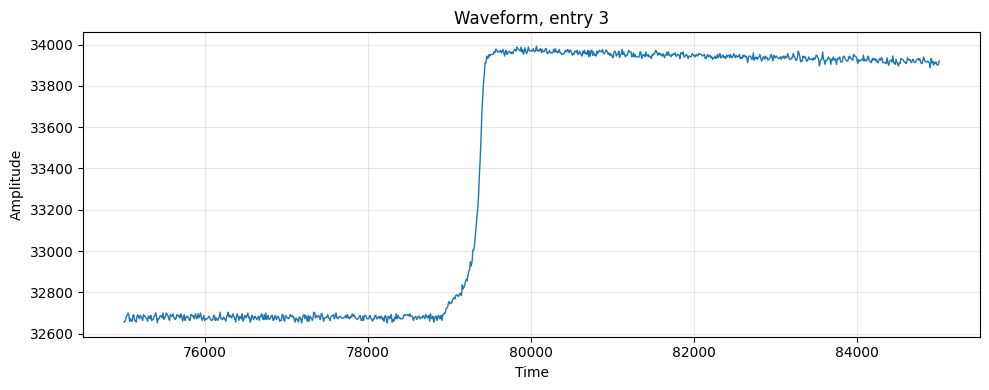

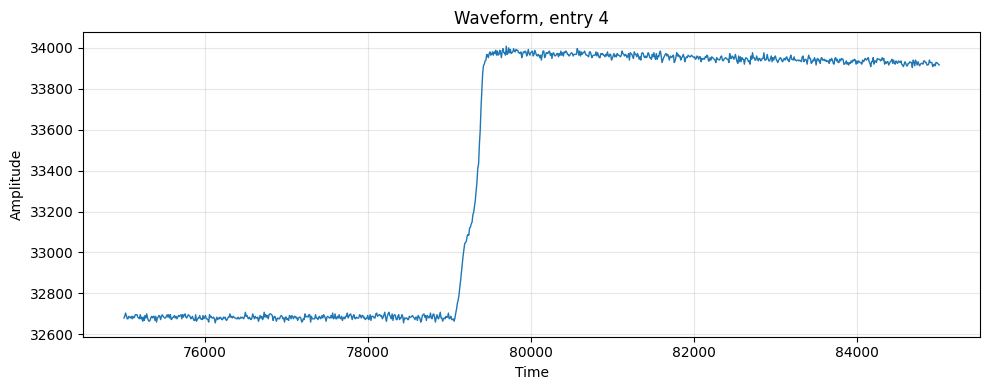

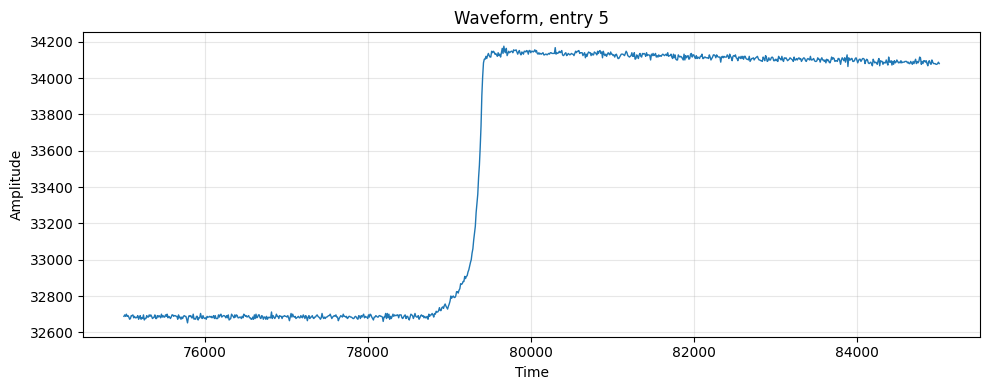

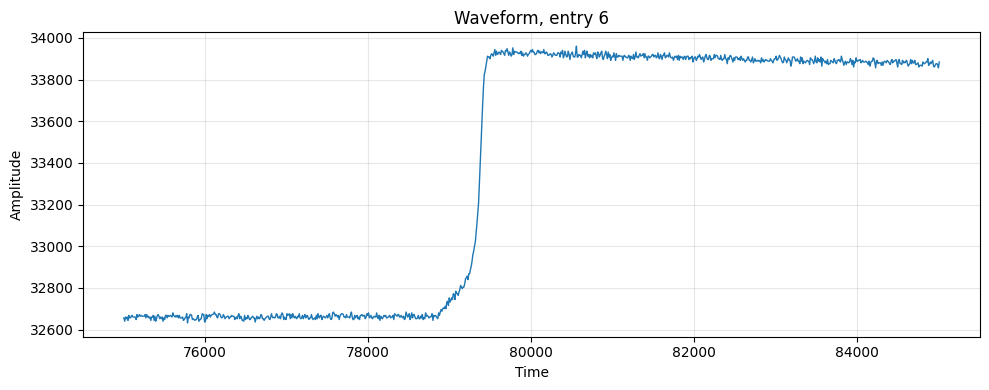

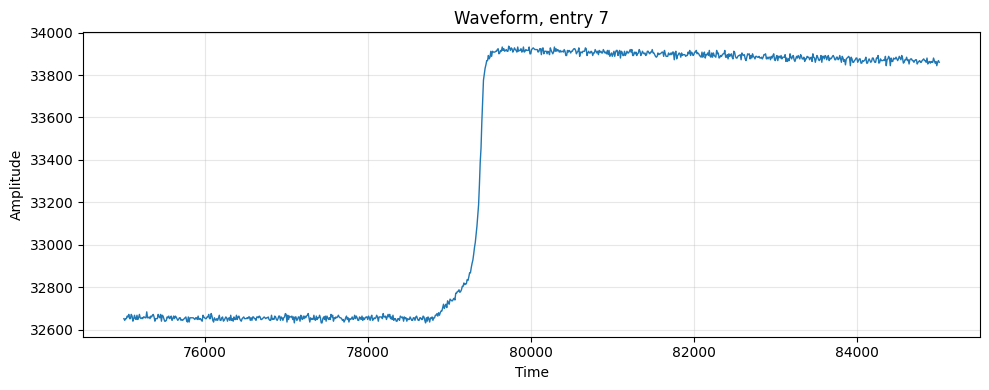

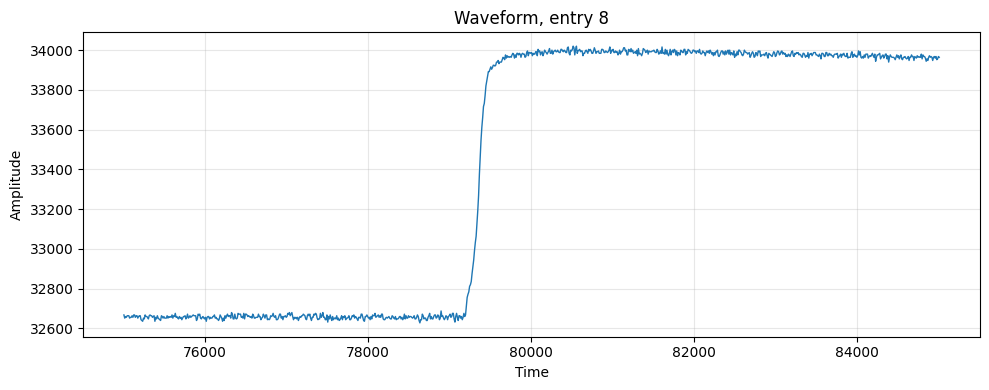

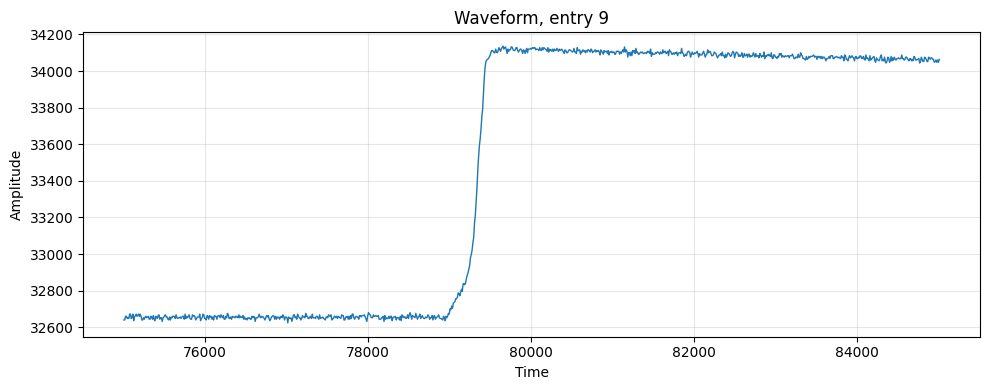

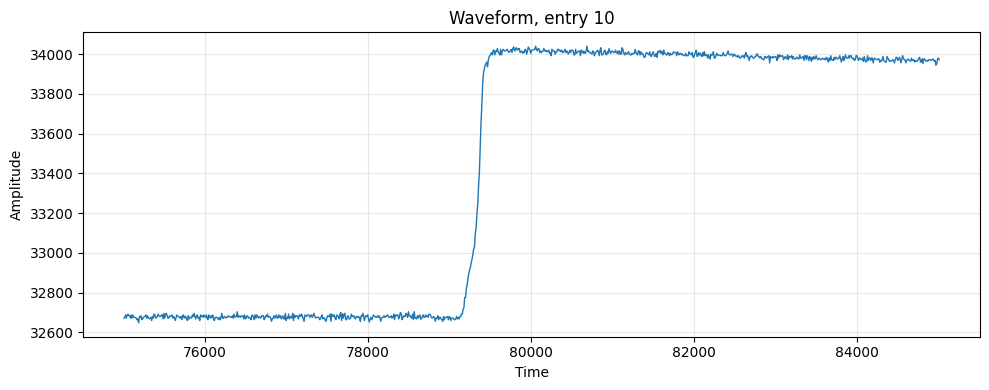

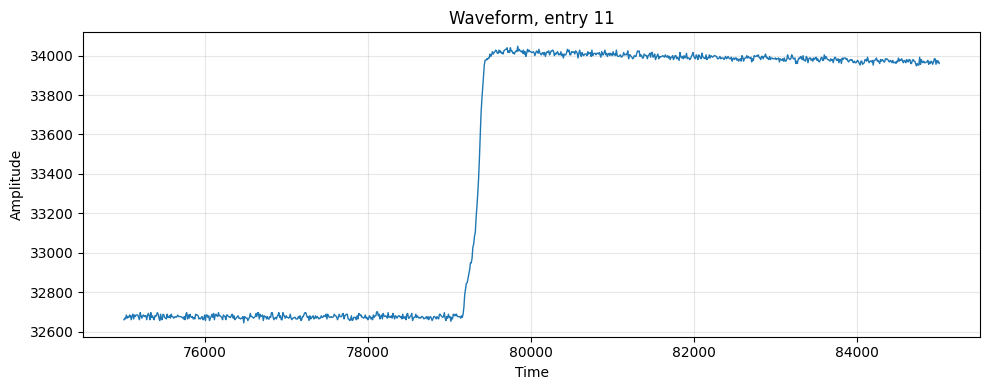

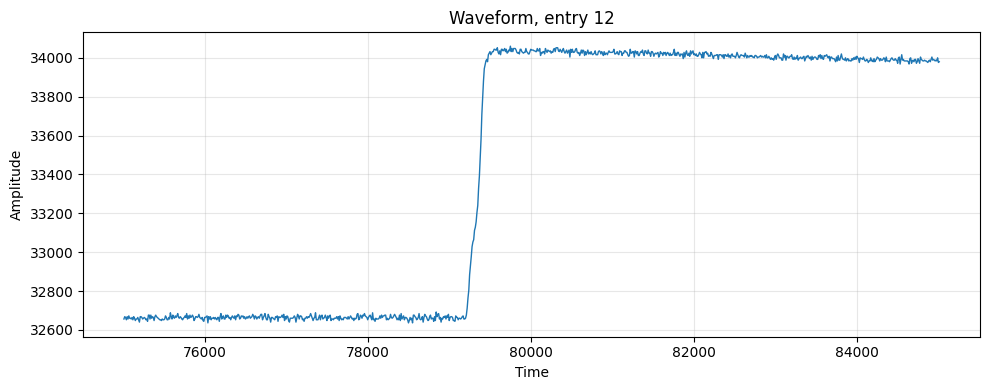

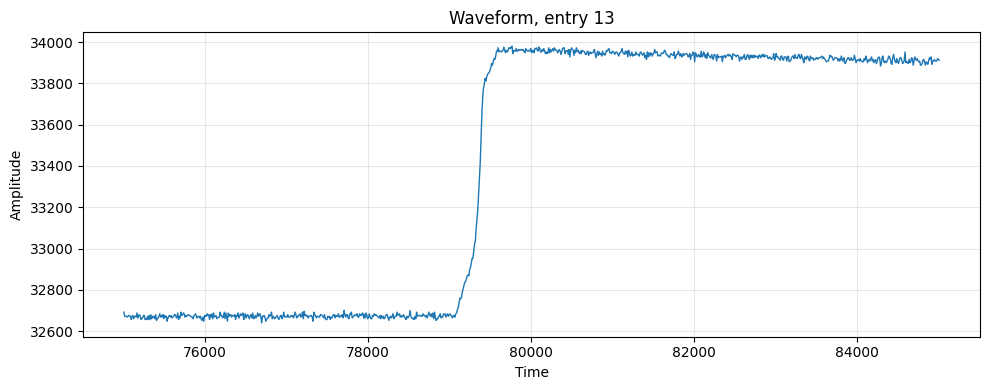

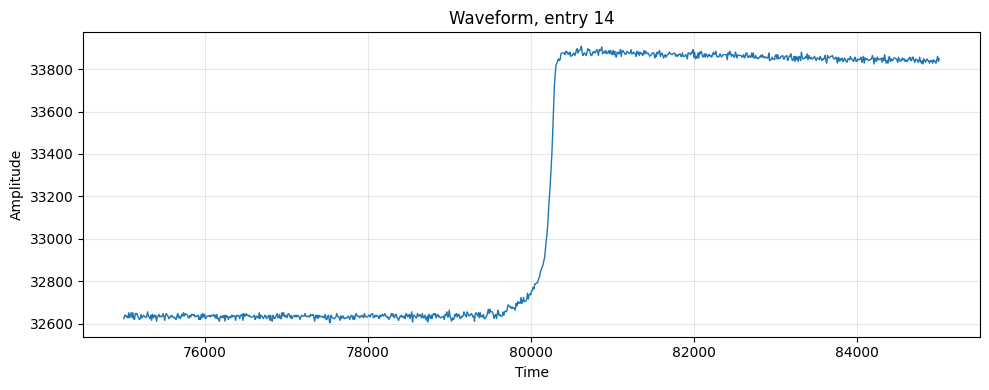

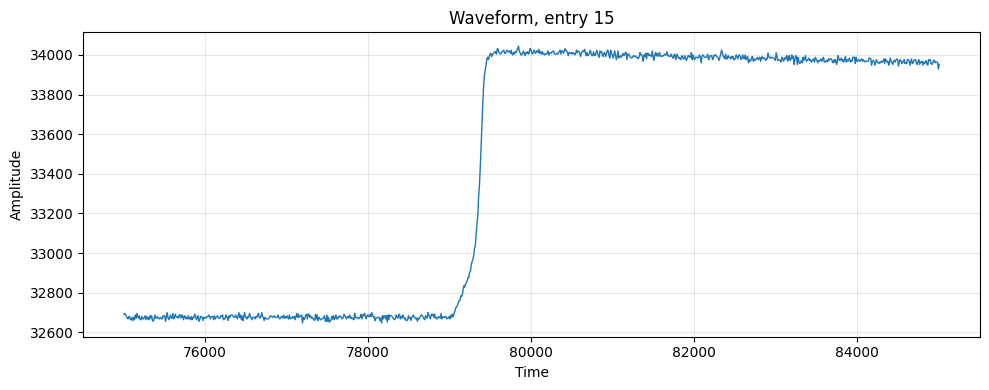

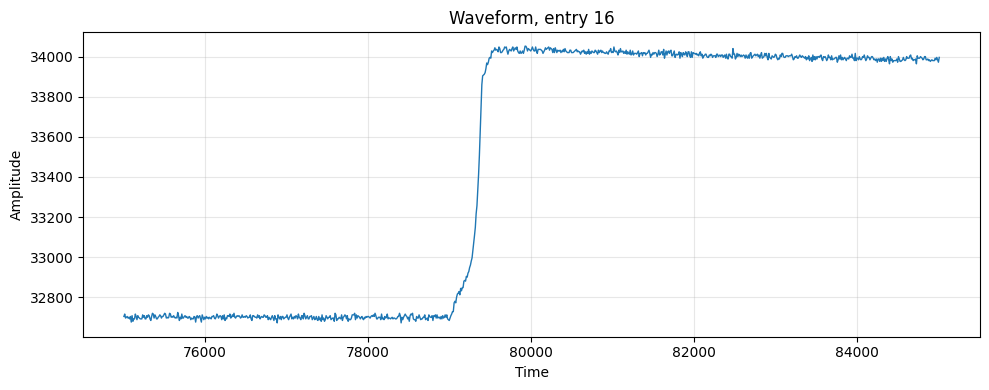

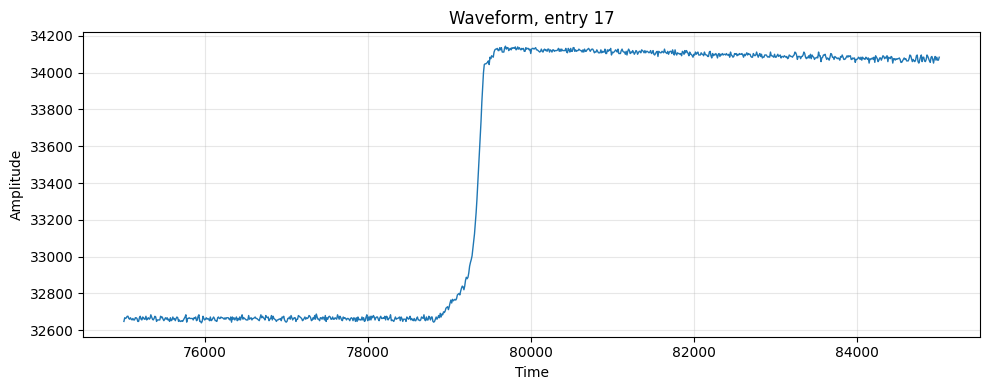

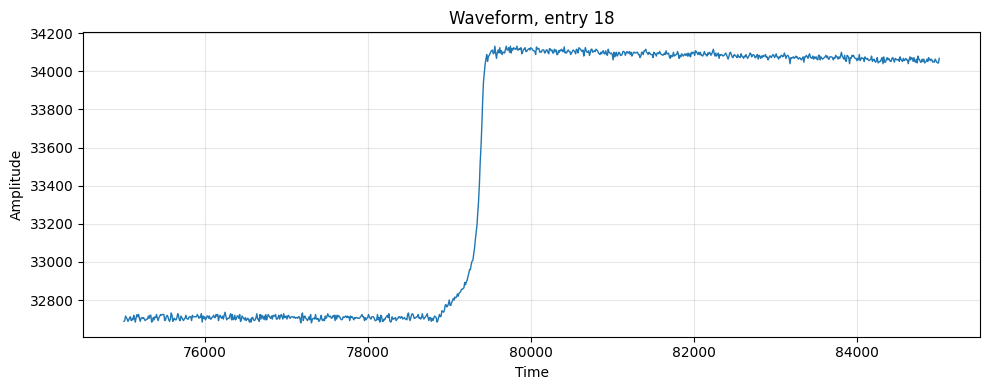

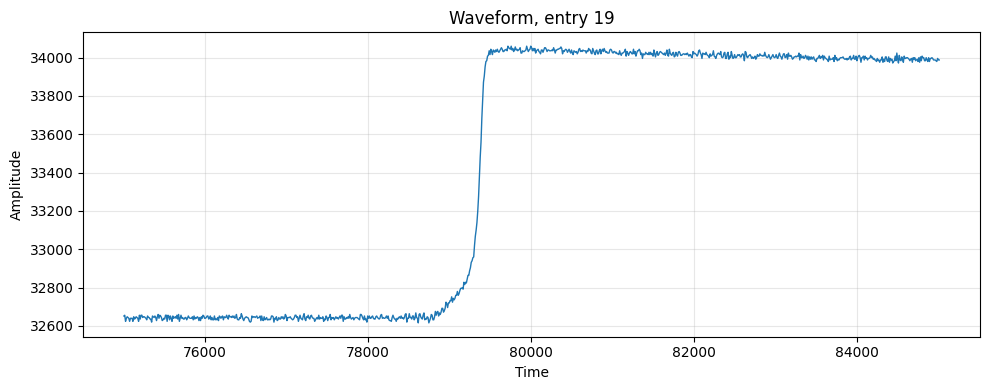

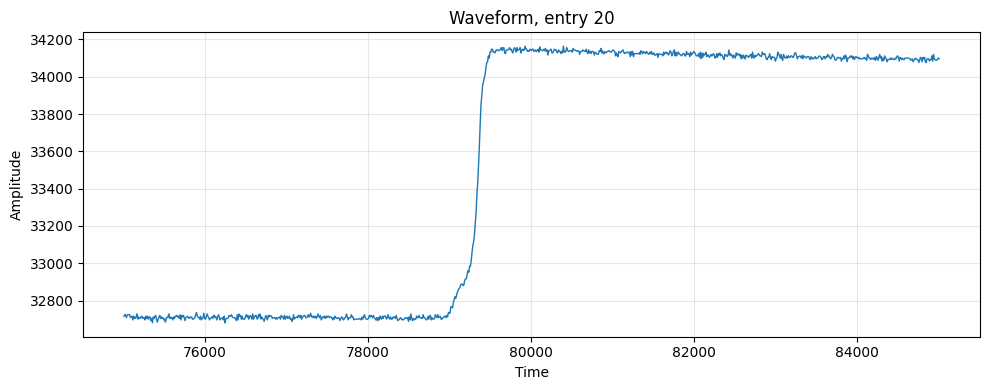

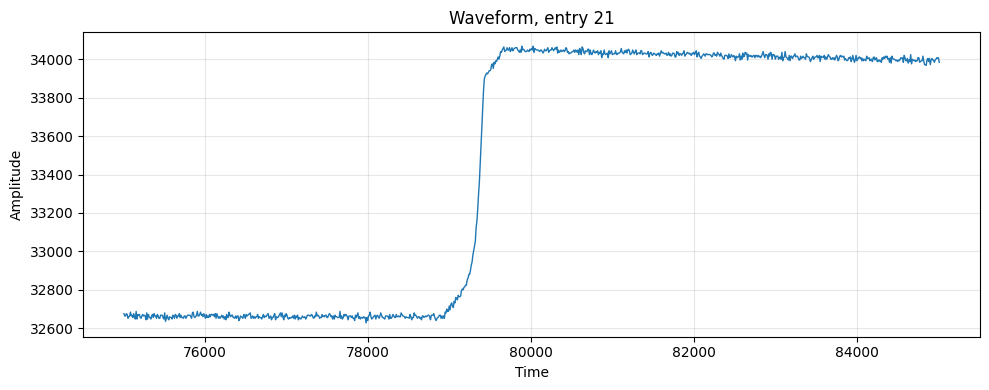

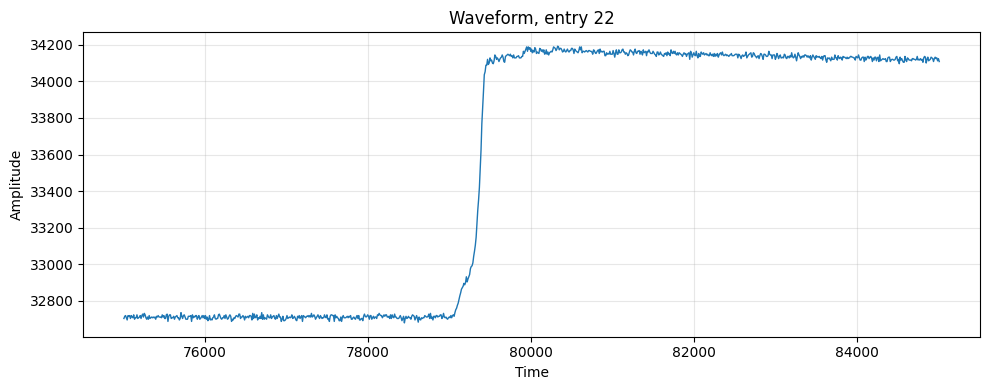

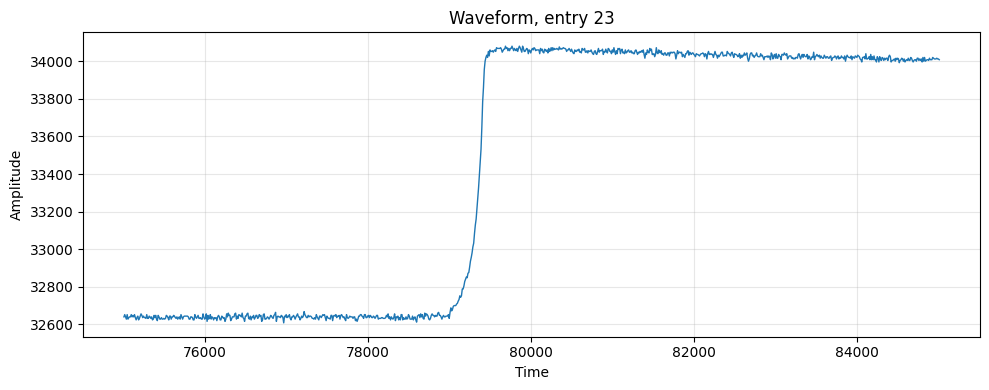

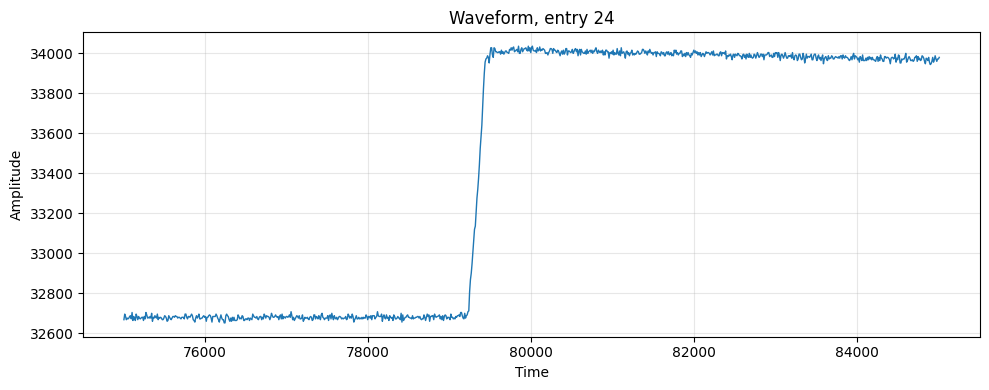

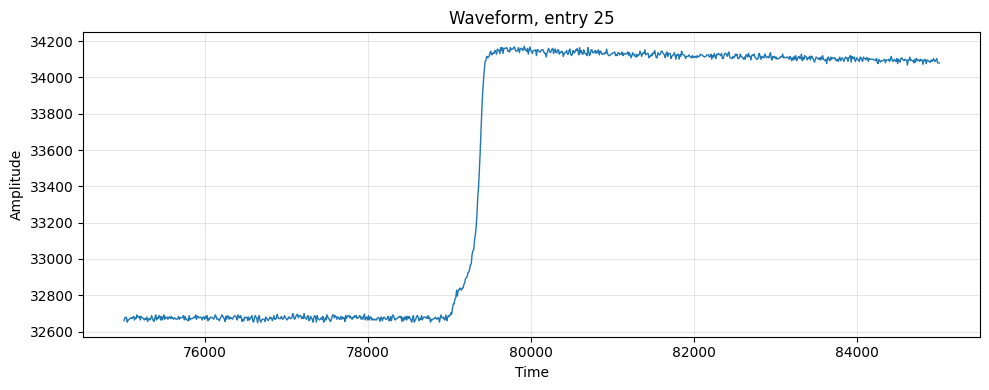

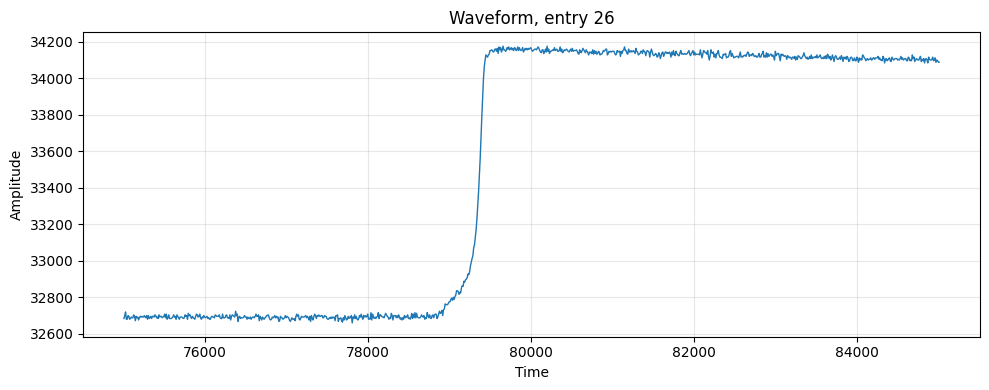

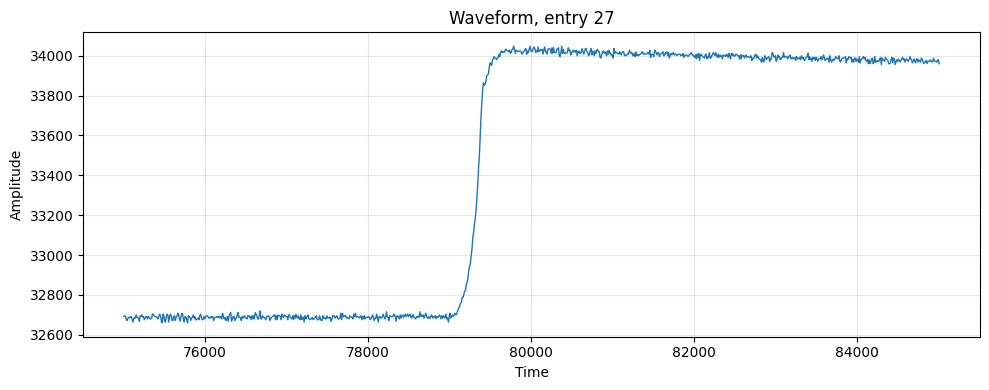

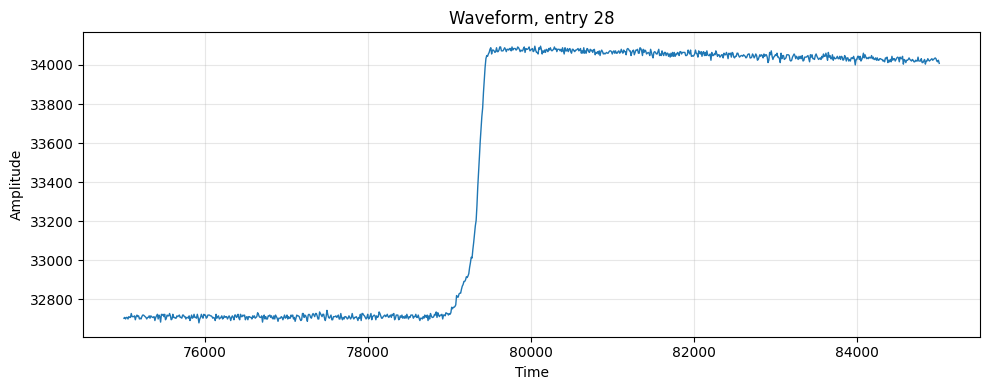

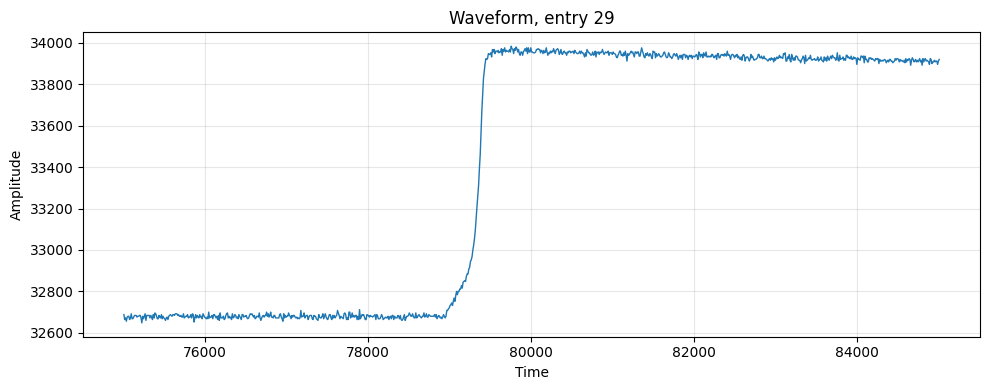

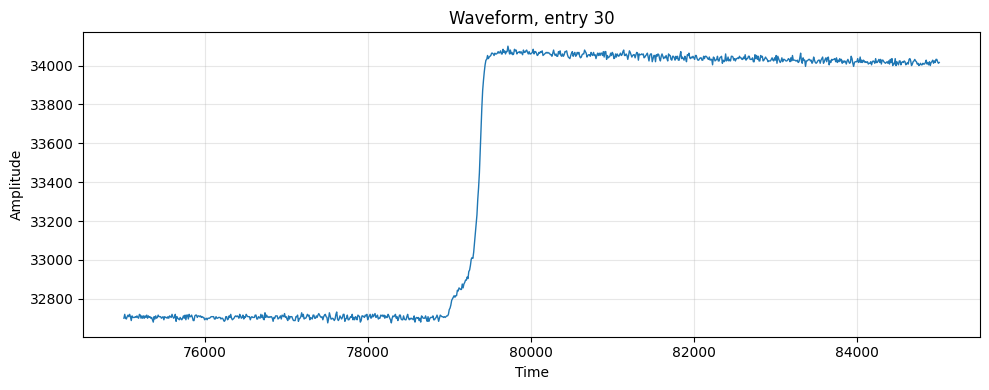

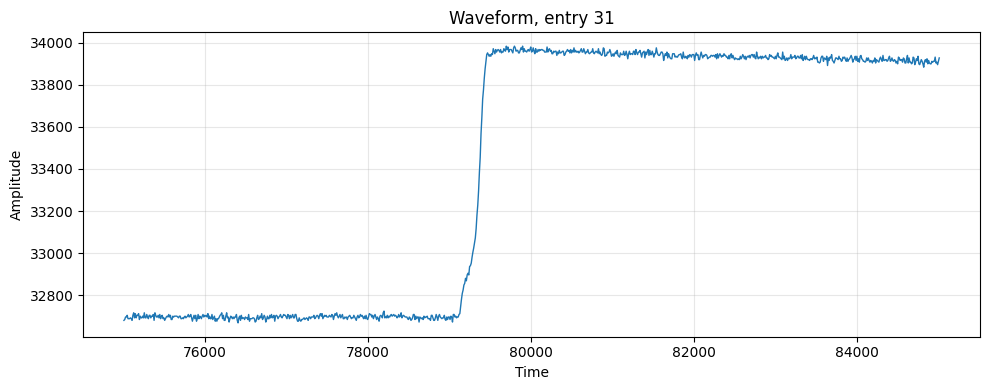

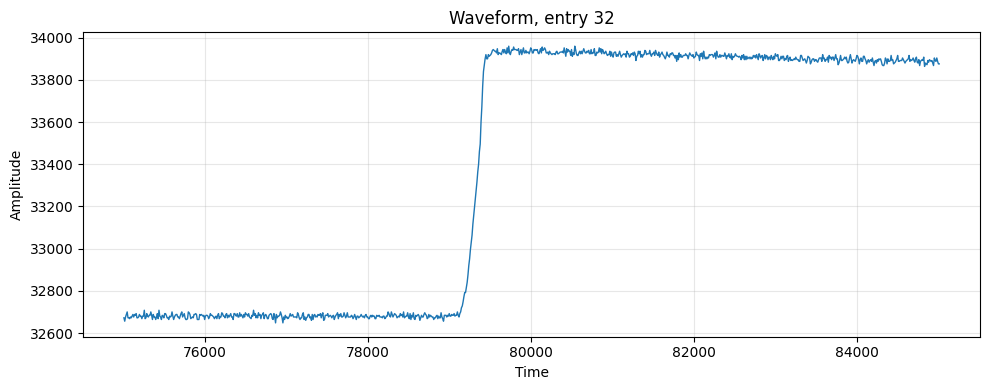

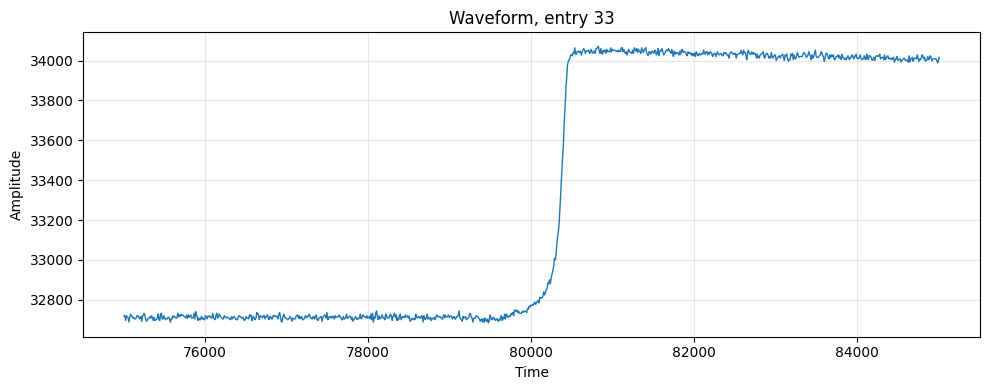

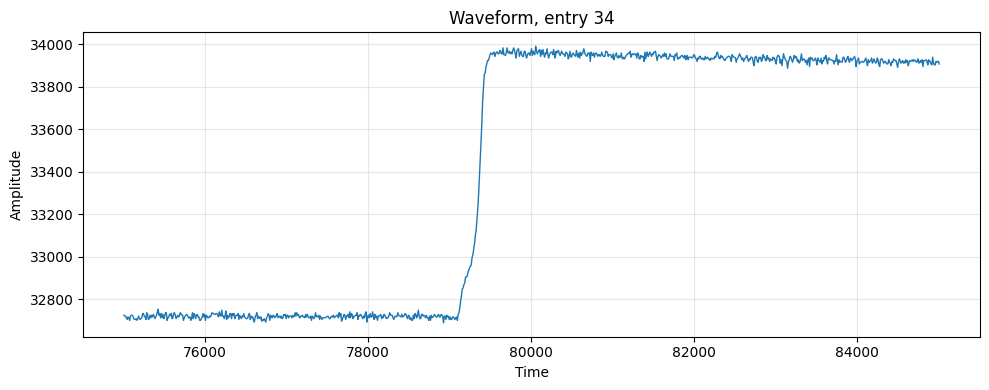

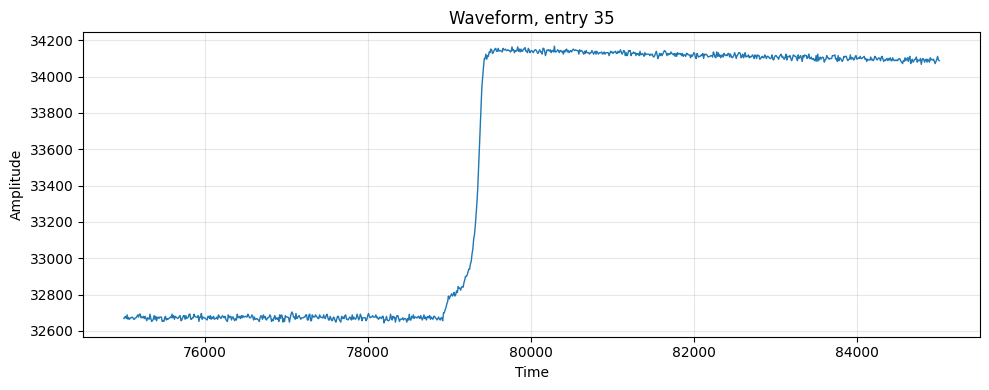

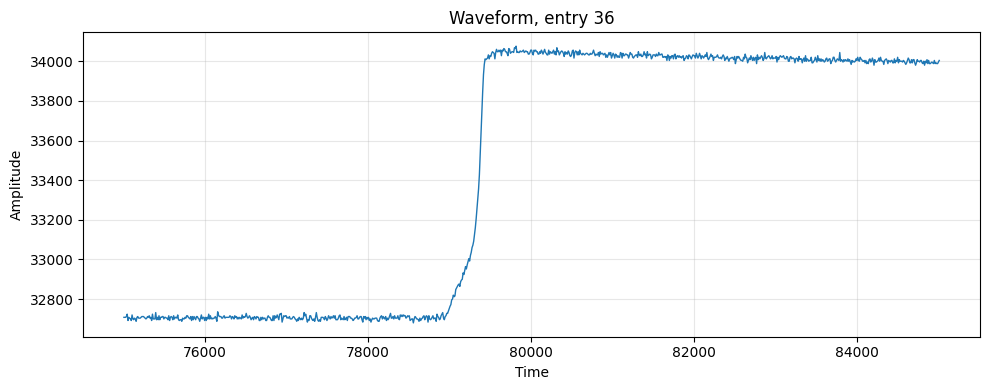

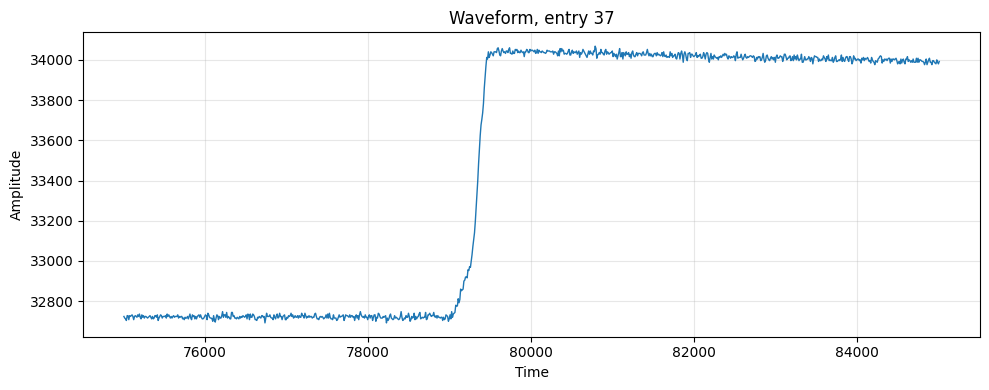

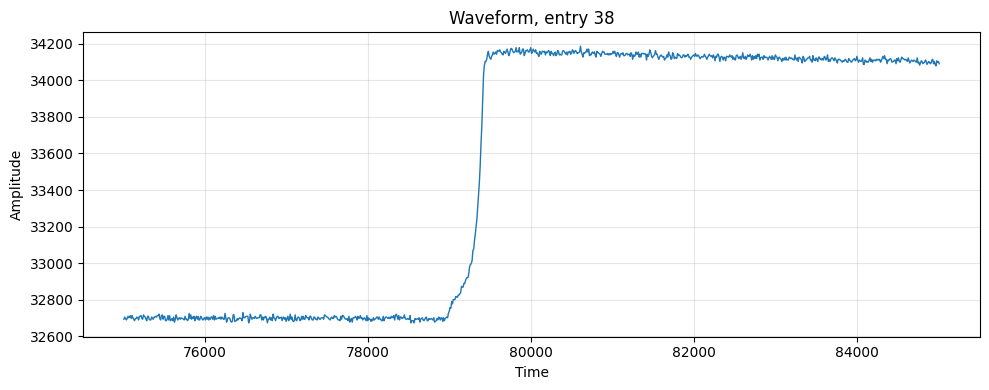

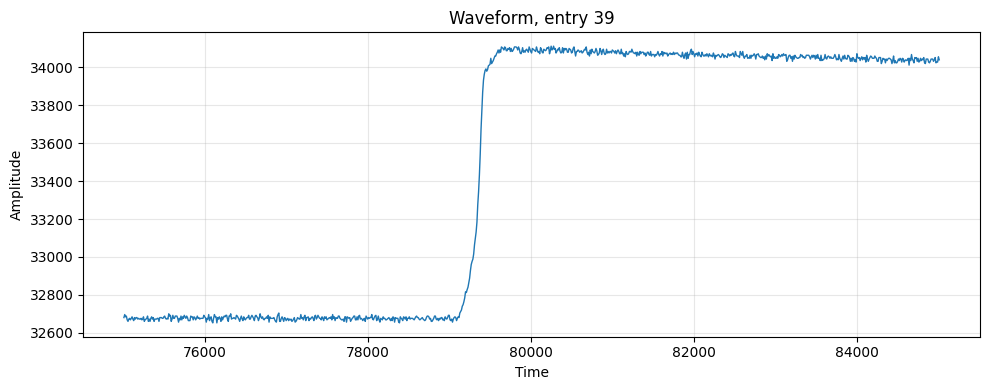

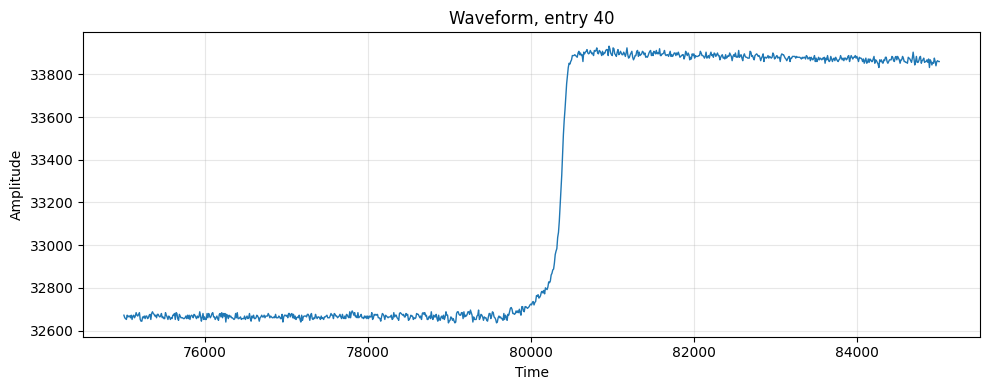

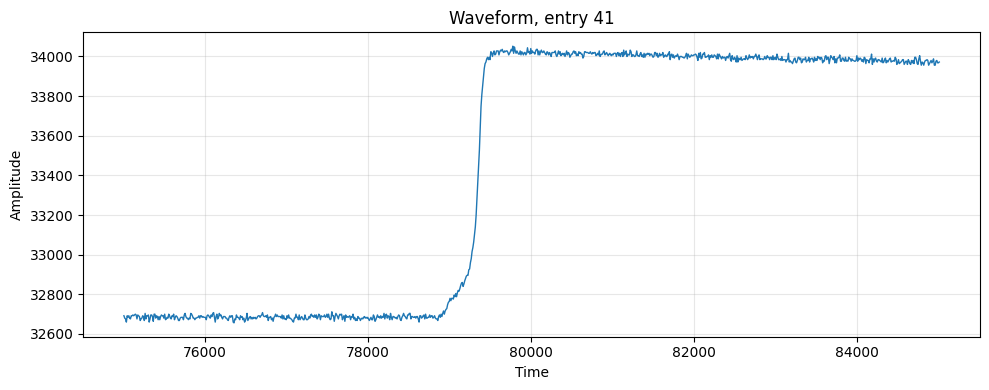

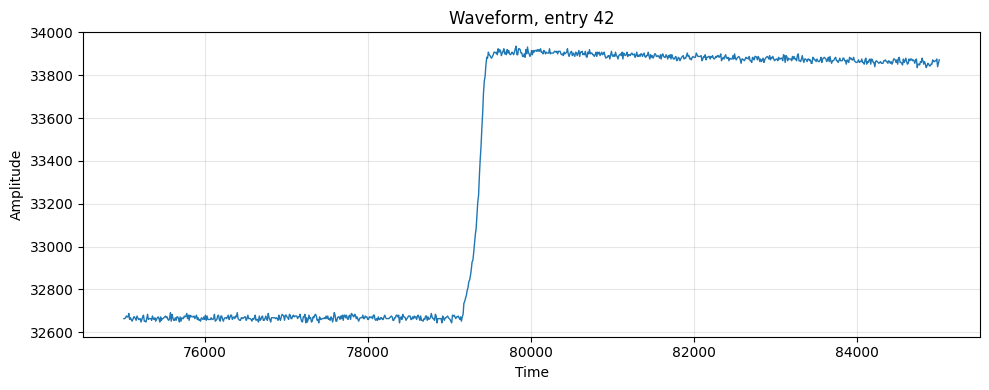

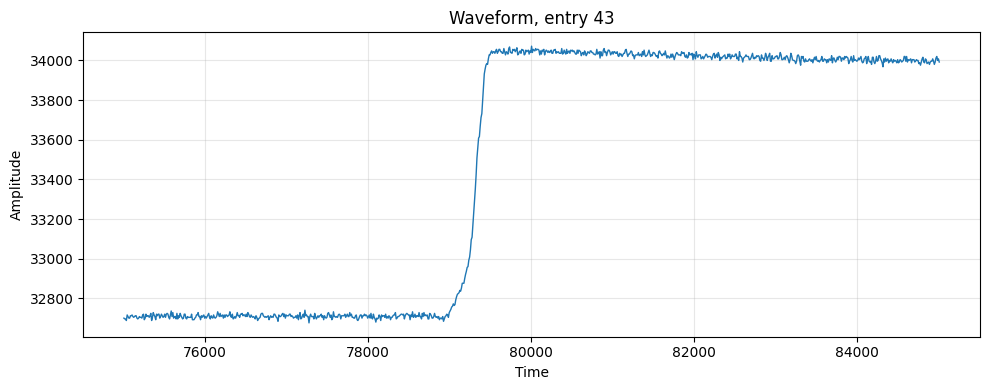

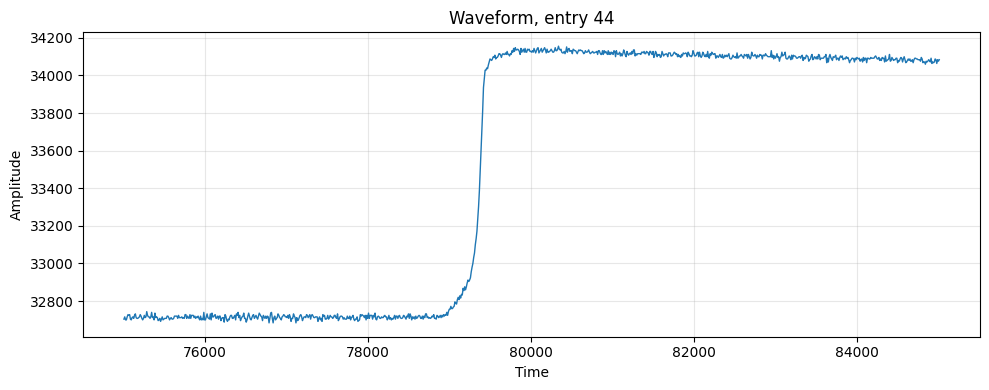

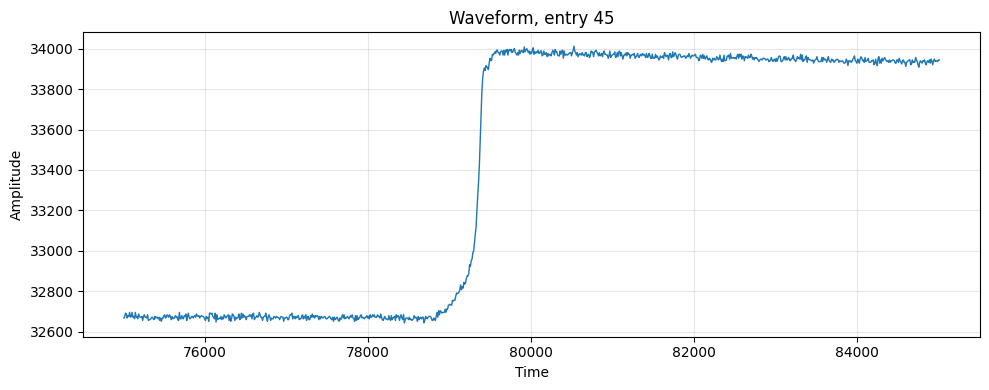

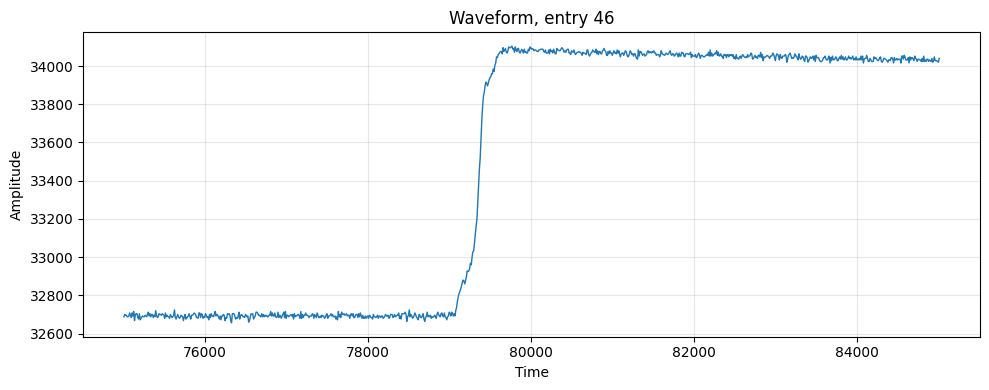

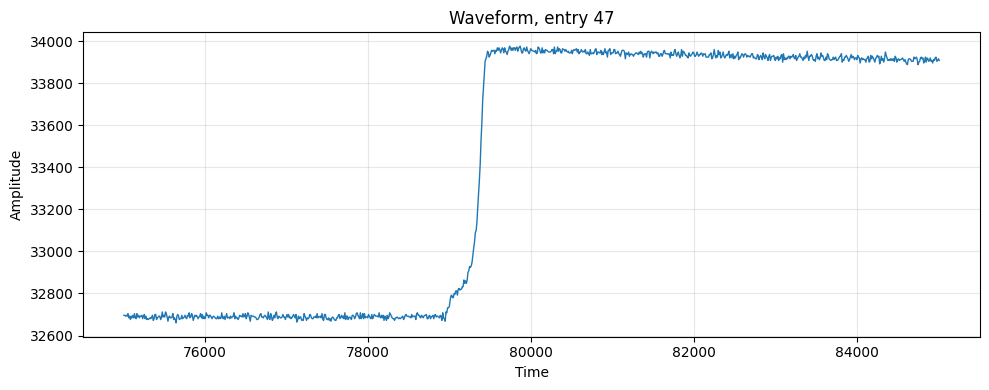

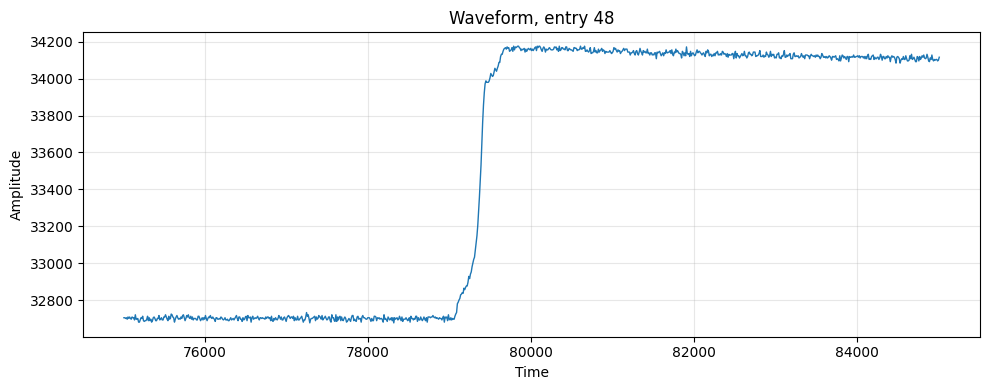

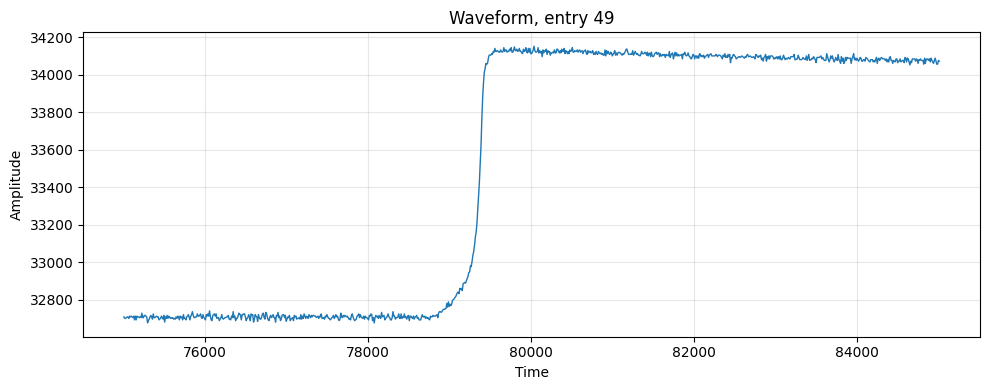

In [ ]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
for entry in range (0,50):
    t0 = masked_data_raw["waveform_windowed"]["t0"][entry]
    dt = masked_data_raw["waveform_windowed"]["dt"][entry]
    values = masked_data_raw["waveform_windowed"]["values"][entry]

    # Convert Awkward data to NumPy
    values = ak.to_numpy(values)
    t0 = float(t0)
    dt = float(dt)

    time = t0 + np.arange(len(values)) * dt

    plt.figure(figsize=(10, 4))

    plt.plot(time, values, lw=1)
    # plt.xlim(78750,80000)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title(f"Waveform, entry {entry}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()